# MNIST Embeddings & Clustering

Compare deterministic, probabilistic, and post-hoc uncertainty approaches on MNIST:
- **Deterministic**: MLP, CNN (NonLinearEmbedder)
- **Probabilistic**: UncertainGen (two-phase), TwoHeadNetwork (joint)
- **Post-hoc**: LLA-KFAC on pre-trained MLP and CNN

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, accuracy_score, f1_score

from datasets.image_contrastive import ImageContrastiveDataset
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.two_head_network import TwoHeadNetworkEmbedder, train_two_head_network
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from features.image import CNNFeatureExtractor
from clustering.gmm import GMMClusterer
from train import train_contrastive
from evaluation.eval_utils import align_labels_via_hungarian_algorithm

SEED = 26042024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

## 1. Load Data

In [ ]:
train_ds = ImageContrastiveDataset(
    dataset_name="mnist", split="train",
    neg_sample_per_pos=20, max_samples=10000,
    data_root="../../data", seed=SEED,
    augmentation_mode=True,
    rotation_range=15.0,
    translation_range=(0.1, 0.1),
)

# Load test set separately for evaluation
import torchvision, torchvision.transforms as T
test_ds = torchvision.datasets.MNIST(root="../../data", train=False, download=True, transform=T.ToTensor())
test_images = np.array([test_ds[i][0].reshape(-1).numpy() for i in range(len(test_ds))])
test_labels = np.array([test_ds[i][1] for i in range(len(test_ds))])
print(f"Train: {len(train_ds)} samples, Test: {len(test_images)} samples, Feature dim: {train_ds.feature_dim}")

## 2. Train Models

Seven embedding variants:
- **MLP**: Deterministic, flattened pixels → MLP encoder
- **CNN**: Deterministic, flattened pixels → CNN → MLP encoder (end-to-end)
- **UncertainGen**: Probabilistic (separate mean/var networks), CNN feature extractor → MLP, two-phase training
- **TwoHeadNetwork**: Probabilistic (shared CNN backbone → split mean/var heads), joint training
- **LLA-MLP**: Post-hoc Laplace Last-Layer (KFAC) on pre-trained MLP — adds Gaussian uncertainty without retraining
- **LLA-CNN**: Post-hoc Laplace Last-Layer (KFAC) on pre-trained CNN — adds Gaussian uncertainty without retraining
- **UG+LLA**: UncertainGen + Laplace Last-Layer — aleatoric (UG) + epistemic (LLA) variance, summed

In [ ]:
DIM = 64
EPOCHS = 150
UG_P2_EPOCHS = 150
LR = 0.001
BATCH_SIZE = 256
NUM_WORKERS = 4

In [ ]:
# --- Save/Load Configuration ---
# Set LOAD_MODELS=True to skip training and load from disk.
# Note: loaded models use the architecture baked into the checkpoint,
# not the DIM/EPOCHS values above.
MODEL_DIR = "../../models/mnist"
LOAD_MODELS = True
SAVE_MODELS = True

os.makedirs(MODEL_DIR, exist_ok=True)

MLP_PATH = os.path.join(MODEL_DIR, "mlp.model")
CNN_PATH = os.path.join(MODEL_DIR, "cnn.model")
UG_PATH  = os.path.join(MODEL_DIR, "uncertaingen.model")
THN_PATH = os.path.join(MODEL_DIR, "thn.model")

MLP_LOSS_PATH = os.path.join(MODEL_DIR, "mlp_loss.npy")
CNN_LOSS_PATH = os.path.join(MODEL_DIR, "cnn_loss.npy")
UG_LOSS_P1_PATH = os.path.join(MODEL_DIR, "ug_loss_p1.npy")
UG_LOSS_P2_PATH = os.path.join(MODEL_DIR, "ug_loss_p2.npy")
THN_LOSS_PATH = os.path.join(MODEL_DIR, "thn_loss.npy")

In [ ]:
# --- Model 1: MLP ---
print(MLP_PATH)
if LOAD_MODELS and os.path.exists(MLP_PATH):
    model_mlp = NonLinearEmbedder.load(MLP_PATH, device=DEVICE)
    loss_mlp = list(np.load(MLP_LOSS_PATH))
    print(f"MLP loaded from {MLP_PATH}")
else:
    set_seed(SEED)
    model_mlp = NonLinearEmbedder(input_dim=train_ds.feature_dim, dim=DIM, device=DEVICE, seed=SEED)
    loss_mlp = train_contrastive(
        model=model_mlp, dataset=train_ds, loss_fn=contrastive_loss,
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_mlp.save(MLP_PATH)
        np.save(MLP_LOSS_PATH, np.array(loss_mlp))
        print(f"MLP saved to {MLP_PATH}")
    print("MLP training done.")

In [ ]:
# --- Model 2: CNN end-to-end ---
# CNN architecture must be recreated for both training and loading
cnn = CNNFeatureExtractor(in_channels=1, image_size=28, output_dim=256)

if LOAD_MODELS and os.path.exists(CNN_PATH):
    model_cnn = NonLinearEmbedder.load(CNN_PATH, device=DEVICE, feature_extractor=cnn)
    loss_cnn = list(np.load(CNN_LOSS_PATH))
    print(f"CNN loaded from {CNN_PATH}")
else:
    set_seed(SEED)
    model_cnn = NonLinearEmbedder(feature_extractor=cnn, dim=DIM, device=DEVICE, seed=SEED)
    loss_cnn = train_contrastive(
        model=model_cnn, dataset=train_ds, loss_fn=contrastive_loss,
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_cnn.save(CNN_PATH)
        np.save(CNN_LOSS_PATH, np.array(loss_cnn))
        print(f"CNN saved to {CNN_PATH}")
    print("CNN training done.")

In [ ]:
# --- Model 3: UncertainGen (probabilistic, CNN feature extractor) ---
ug_cnn = CNNFeatureExtractor(in_channels=1, image_size=28, output_dim=256)

if LOAD_MODELS and os.path.exists(UG_PATH):
    model_ug = UncertainGenEmbedder.load(UG_PATH, device=DEVICE, feature_extractor=ug_cnn)
    loss_ug_p1 = list(np.load(UG_LOSS_P1_PATH))
    loss_ug_p2 = list(np.load(UG_LOSS_P2_PATH))
    print(f"UncertainGen loaded from {UG_PATH}")
else:
    set_seed(SEED)
    model_ug = UncertainGenEmbedder(
        feature_extractor=ug_cnn, dim=DIM, k_form="adaptive",
        device=DEVICE, seed=SEED,
    )
    # Phase 1: mean network + CNN feature extractor
    loss_ug_p1 = train_contrastive(
        model=model_ug, dataset=train_ds, loss_fn=contrastive_loss,
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, parameters=model_ug.mean_parameters(), verbose=True,
    )
    # Phase 2: freeze mean+CNN, train variance network only
    loss_ug_p2 = train_variance_phase(
        model=model_ug, dataset=train_ds,
        lr=LR, epochs=UG_P2_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_ug.save(UG_PATH)
        np.save(UG_LOSS_P1_PATH, np.array(loss_ug_p1))
        np.save(UG_LOSS_P2_PATH, np.array(loss_ug_p2))
        print(f"UncertainGen saved to {UG_PATH}")
    print("UncertainGen training done.")

In [ ]:
# --- Model 4: TwoHeadNetwork (shared CNN backbone, split heads) ---
# Backbone architecture must be recreated for both training and loading
thn_backbone = CNNFeatureExtractor(in_channels=1, image_size=28, output_dim=256)

if LOAD_MODELS and os.path.exists(THN_PATH):
    model_thn = TwoHeadNetworkEmbedder.load(THN_PATH, device=DEVICE, backbone=thn_backbone)
    loss_thn = list(np.load(THN_LOSS_PATH))
    print(f"TwoHeadNetwork loaded from {THN_PATH}")
else:
    set_seed(SEED)
    model_thn = TwoHeadNetworkEmbedder(backbone=thn_backbone, backbone_dim=256, dim=DIM,
                             k_form="adaptive", device=DEVICE, seed=SEED)
    loss_thn = train_two_head_network(
        model=model_thn, dataset=train_ds,
        lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        num_workers=NUM_WORKERS, verbose=True,
    )
    if SAVE_MODELS:
        model_thn.save(THN_PATH)
        np.save(THN_LOSS_PATH, np.array(loss_thn))
        print(f"TwoHeadNetwork saved to {THN_PATH}")
    print("TwoHeadNetwork training done.")

In [185]:
# --- Model 5 & 6: LLA (Laplace Last-Layer) on pre-trained MLP and CNN ---
# No retraining — just compute KFAC factors from the contrastive loss curvature
# at the last linear layer of each pre-trained model.
# Prior precision is tuned via marginal likelihood (MacKay, 1992).

LLA_PRIOR = 1.0  # initial value, optimized below

print("=== LLA on MLP ===")
lla_mlp = LaplaceLastLayerEmbedder(model_mlp, prior_precision=LLA_PRIOR)
lla_mlp.fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
lla_mlp.optimize_prior()

print("\n=== LLA on CNN ===")
lla_cnn = LaplaceLastLayerEmbedder(model_cnn, prior_precision=LLA_PRIOR)
lla_cnn.fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
lla_cnn.optimize_prior()

=== LLA on MLP ===


 LLA fit │██████████████████████████████│ 157/157 [00:01<00:00]


LLA fitted on 420000 samples (B: GGN).
  S_A range: [1.65e-05, 4.23e+01]
  S_B range: [9.58e-02, 2.13e-01]
  prior converged at step 21: tau=867.1736, gamma=9222.2/32832
  optimized prior_precision = 867.1730

=== LLA on CNN ===


 LLA fit │██████████████████████████████│ 157/157 [00:04<00:00]

LLA fitted on 420000 samples (B: GGN).
  S_A range: [1.00e-06, 5.27e+01]
  S_B range: [9.55e-02, 7.92e-01]
  prior converged at step 20: tau=205.4738, gamma=2430.3/32832
  optimized prior_precision = 205.4738


In [186]:
# --- Model 7: UG+LLA (UncertainGen + Laplace Last-Layer) ---
# Combines aleatoric uncertainty (UG's trained variance network) with
# epistemic uncertainty (LLA's Laplace approximation on the last layer).
# Final variance = UG_variance + LLA_variance.
#
# LLA expects base_model.linear2 — alias UG's mean_linear2 for compatibility.
model_ug.linear2 = model_ug.mean_linear2

print("=== LLA on UncertainGen ===")
lla_ug = LaplaceLastLayerEmbedder(model_ug, prior_precision=LLA_PRIOR)
lla_ug.fit(train_ds, contrastive_loss, batch_size=64, device=DEVICE)
lla_ug.optimize_prior()

=== LLA on UncertainGen ===


 LLA fit │██████████████████████████████│ 157/157 [00:03<00:00]

LLA fitted on 420000 samples (B: GGN).
  S_A range: [1.00e-06, 5.33e+01]
  S_B range: [9.54e-02, 8.13e-01]
  prior converged at step 20: tau=200.7310, gamma=2345.3/32832
  optimized prior_precision = 200.7311


In [ ]:
# --- Training Loss Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all models on one plot
n_epochs = len(loss_mlp)
epochs_x = range(1, n_epochs + 1)
axes[0].plot(epochs_x, loss_mlp, label="MLP", linewidth=2)
axes[0].plot(epochs_x, loss_cnn, label="CNN", linewidth=2)
axes[0].plot(range(1, len(loss_ug_p1) + 1), loss_ug_p1, label="UncertainGen (Phase 1)", linewidth=2)
axes[0].plot(epochs_x, loss_thn, label="TwoHeadNetwork", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: UncertainGen Phase 1 + Phase 2 combined
ug_combined = loss_ug_p1 + loss_ug_p2
epochs_combined = range(1, len(ug_combined) + 1)
phase_boundary = len(loss_ug_p1)
axes[1].plot(epochs_combined, ug_combined, label="UncertainGen", linewidth=2, color="C2")
axes[1].axvline(x=phase_boundary, color="gray", linestyle="--", alpha=0.7,
                label=f"Phase 1\u21922 (epoch {phase_boundary})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("UncertainGen: Phase 1 + Phase 2")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final losses:")
print(f"  MLP:                {loss_mlp[-1]:.6f}")
print(f"  CNN:                {loss_cnn[-1]:.6f}")
print(f"  UncertainGen (P1):  {loss_ug_p1[-1]:.6f}")
print(f"  UncertainGen (P2):  {loss_ug_p2[-1]:.6f}")
print(f"  TwoHeadNetwork:     {loss_thn[-1]:.6f}")

## 3. Embed Test Set

In [ ]:
emb_mlp = model_mlp.embed(test_images)
emb_cnn = model_cnn.embed(test_images)
emb_ug = model_ug.embed(test_images)
emb_thn = model_thn.embed(test_images)
emb_lla_mlp = lla_mlp.embed(test_images)
emb_lla_cnn = lla_cnn.embed(test_images)

# UG+LLA: aleatoric (UG) + epistemic (LLA) variance
emb_lla_ug_only = lla_ug.embed(test_images)  # LLA variance on UG's mean network
emb_ug_lla = EmbeddingResult(
    mean=emb_ug.mean,
    variance=emb_ug.variance + emb_lla_ug_only.variance,
)

print(f"MLP embeddings:       mean {emb_mlp.mean.shape}")
print(f"CNN embeddings:       mean {emb_cnn.mean.shape}")
print(f"UncertainGen:         mean {emb_ug.mean.shape}, variance {emb_ug.variance.shape}")
print(f"TwoHeadNetwork:       mean {emb_thn.mean.shape}, variance {emb_thn.variance.shape}")
print(f"LLA-MLP:              mean {emb_lla_mlp.mean.shape}, variance {emb_lla_mlp.variance.shape}")
print(f"LLA-CNN:              mean {emb_lla_cnn.mean.shape}, variance {emb_lla_cnn.variance.shape}")
print(f"UG+LLA:               mean {emb_ug_lla.mean.shape}, variance {emb_ug_lla.variance.shape}")

## 4. Cluster & Evaluate

Two clustering algorithms:
- **K-Means** (k=10) — baseline, ignores variance
- **GMM** (k=10, uncertainty-aware) — uses variance from probabilistic embeddings to weight cluster assignments

Note: LLA-MLP and LLA-CNN have the same point estimates as MLP and CNN respectively,
so K-Means results are identical. GMM results differ because
it uses variance to re-weight assignments.

In [ ]:
def score_predictions(pred, true_labels, name):
    """Compute clustering metrics over the FULL test set.

    Unassigned samples (pred == -1) count as incorrect for acc/F1
    and as a separate cluster for NMI/ARI.
    """
    mask = pred != -1
    n_assigned = mask.sum()
    n_total = len(true_labels)
    coverage = n_assigned / n_total

    if n_assigned == 0:
        print(f"{name:35s}  Acc=0.0000  NMI=0.0000  ARI=0.0000  F1=0.0000  "
              f"k=0  cov={coverage:.1%}")
        return {"name": name, "acc": 0, "nmi": 0, "ari": 0, "f1": 0,
                "k": 0, "coverage": 0.0}

    # Hungarian alignment on assigned samples
    label_map = align_labels_via_hungarian_algorithm(true_labels[mask], pred[mask])

    # Build full-set aligned predictions: assigned get mapped label, unassigned get -1
    full_aligned = np.full(n_total, -1)
    full_aligned[mask] = np.array([label_map.get(p, p) for p in pred[mask]])

    # Accuracy over full set: unassigned are always wrong
    acc = accuracy_score(true_labels, full_aligned)
    # NMI/ARI over full set: -1 treated as its own cluster
    nmi = normalized_mutual_info_score(true_labels, pred)
    ari = adjusted_rand_score(true_labels, pred)
    # F1 over full set: unassigned (-1) won't match any true label
    f1 = f1_score(true_labels, full_aligned, average="macro", zero_division=0)
    n_clusters = len(set(pred[mask]))

    print(f"{name:35s}  Acc={acc:.4f}  NMI={nmi:.4f}  ARI={ari:.4f}  F1={f1:.4f}  "
          f"k={n_clusters}  cov={coverage:.1%}")
    return {"name": name, "acc": acc, "nmi": nmi, "ari": ari, "f1": f1,
            "k": n_clusters, "coverage": coverage}


all_embs = [
    (emb_mlp, "MLP"), (emb_cnn, "CNN"),
    (emb_ug, "UncertainGen"), (emb_thn, "TwoHeadNetwork"),
    (emb_lla_mlp, "LLA-MLP"), (emb_lla_cnn, "LLA-CNN"),
    (emb_ug_lla, "UG+LLA"),
]

# --- K-Means (k=10) ---
print("=== K-Means (k=10) ===")
kmeans_results = []
for emb, name in all_embs:
    km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
    pred = km.fit_predict(emb.mean)
    kmeans_results.append(score_predictions(pred, test_labels, f"KMeans / {name}"))

# --- GMM (k=10, uncertainty-aware) ---
print("\n=== GMM (k=10, uncertainty-aware) ===")
gmm_results = []
for emb, name in all_embs:
    gmm = GMMClusterer(n_components=10, random_state=SEED)
    pred = gmm.fit_predict(emb)
    gmm_results.append(score_predictions(pred, test_labels, f"GMM / {name}"))

results = kmeans_results + gmm_results

## 5. Visualize Embeddings (t-SNE)

In [ ]:
# Subsample for faster t-SNE
N_VIS = 3000
rng = np.random.RandomState(SEED)
vis_idx = rng.choice(len(test_labels), N_VIS, replace=False)
vis_labels = test_labels[vis_idx]

embeddings_dict = {
    "MLP": emb_mlp.mean[vis_idx],
    "CNN": emb_cnn.mean[vis_idx],
    "UncertainGen": emb_ug.mean[vis_idx],
    "TwoHeadNetwork": emb_thn.mean[vis_idx],
    "LLA-MLP": emb_lla_mlp.mean[vis_idx],
    "LLA-CNN": emb_lla_cnn.mean[vis_idx],
    "UG+LLA": emb_ug_lla.mean[vis_idx],
}

n_models = len(embeddings_dict)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()
for ax, (name, emb) in zip(axes, embeddings_dict.items()):
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    coords = tsne.fit_transform(emb)
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=vis_labels, cmap="tab10", s=5, alpha=0.7)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
# Hide unused axes
for ax in axes[n_models:]:
    ax.set_visible(False)
plt.colorbar(scatter, ax=axes[n_models - 1], label="Digit")
plt.suptitle("t-SNE of MNIST Embeddings", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Uncertainty Analysis

Compare uncertainty across five probabilistic approaches:
- **UncertainGen**: Separate variance network (trained, Phase 2) — aleatoric only
- **TwoHeadNetwork**: Shared backbone, variance head (jointly trained) — aleatoric only
- **LLA-MLP**: Post-hoc KFAC on MLP last layer (no extra training) — epistemic only
- **LLA-CNN**: Post-hoc KFAC on CNN last layer (no extra training) — epistemic only
- **UG+LLA**: UncertainGen + Laplace on UG's mean network — aleatoric + epistemic

In [ ]:
# Per-sample total uncertainty = sum of variance across dimensions
unc_ug = emb_ug.variance.sum(axis=1)
unc_thn = emb_thn.variance.sum(axis=1)
unc_lla_mlp = emb_lla_mlp.variance.sum(axis=1)
unc_lla_cnn = emb_lla_cnn.variance.sum(axis=1)
unc_ug_lla = emb_ug_lla.variance.sum(axis=1)

prob_models = [
    ("UncertainGen", unc_ug),
    ("TwoHeadNetwork", unc_thn),
    ("LLA-MLP", unc_lla_mlp),
    ("LLA-CNN", unc_lla_cnn),
    ("UG+LLA", unc_ug_lla),
]

ncols = 3
nrows = (len(prob_models) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()
for ax, (name, unc) in zip(axes, prob_models):
    for digit in range(10):
        mask = test_labels == digit
        ax.hist(unc[mask], bins=30, alpha=0.5, label=str(digit), density=True)
    ax.set_xlabel("Total Variance")
    ax.set_ylabel("Density")
    ax.set_title(f"{name}: Uncertainty by Digit")
    ax.legend(ncol=2, fontsize=7)
for ax in axes[len(prob_models):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

# Mean uncertainty per class comparison
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(10)
width = 0.15
for i, (name, unc) in enumerate(prob_models):
    means = [unc[test_labels == d].mean() for d in range(10)]
    ax.bar(x + i * width, means, width, label=name)
ax.set_xlabel("Digit")
ax.set_ylabel("Mean Uncertainty")
ax.set_title("Mean Uncertainty per Digit")
ax.set_xticks(x + 2 * width)
ax.set_xticklabels(range(10))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# t-SNE colored by uncertainty: all probabilistic models
prob_vis_list = [
    ("UncertainGen", emb_ug, unc_ug),
    ("TwoHeadNetwork", emb_thn, unc_thn),
    ("LLA-MLP", emb_lla_mlp, unc_lla_mlp),
    ("LLA-CNN", emb_lla_cnn, unc_lla_cnn),
    ("UG+LLA", emb_ug_lla, unc_ug_lla),
]

fig, axes = plt.subplots(len(prob_vis_list), 2, figsize=(14, 5 * len(prob_vis_list)))

for row, (name, emb_obj, unc) in enumerate(prob_vis_list):
    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
    coords = tsne.fit_transform(emb_obj.mean[vis_idx])
    unc_vis = unc[vis_idx]

    axes[row, 0].scatter(coords[:, 0], coords[:, 1], c=vis_labels, cmap="tab10", s=5, alpha=0.7)
    axes[row, 0].set_title(f"{name}: Colored by Digit")
    sc = axes[row, 1].scatter(coords[:, 0], coords[:, 1], c=unc_vis, cmap="hot", s=5, alpha=0.7)
    plt.colorbar(sc, ax=axes[row, 1], label="Uncertainty")
    axes[row, 1].set_title(f"{name}: Colored by Uncertainty")
    for ax in axes[row]:
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Embedding Space: Digits vs Uncertainty", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Uncertainty Filtering Experiment

**Core claim from UncertainGen**: Discarding high-uncertainty samples before clustering
produces cleaner clusters (higher accuracy at the cost of lower coverage).

For each probabilistic model, we remove the top X% highest-variance samples,
then run K-Means on the remaining low-uncertainty samples and measure accuracy vs coverage.

In [ ]:
# Uncertainty filtering: remove top X% most uncertain, K-Means on the rest
filter_pcts = np.arange(0, 55, 5)  # 0%, 5%, 10%, ..., 50%

prob_embs = [
    ("UncertainGen", emb_ug, unc_ug),
    ("TwoHeadNetwork", emb_thn, unc_thn),
    ("LLA-MLP", emb_lla_mlp, unc_lla_mlp),
    ("LLA-CNN", emb_lla_cnn, unc_lla_cnn),
    ("UG+LLA", emb_ug_lla, unc_ug_lla),
]

filter_results = {name: {"acc": [], "cov": []} for name, _, _ in prob_embs}

for name, emb_obj, unc in prob_embs:
    for pct in filter_pcts:
        if pct == 0:
            keep = np.ones(len(unc), dtype=bool)
        else:
            threshold = np.percentile(unc, 100 - pct)
            keep = unc <= threshold

        km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
        pred = km.fit_predict(emb_obj.mean[keep])
        kept_labels = test_labels[keep]

        label_map = align_labels_via_hungarian_algorithm(kept_labels, pred)
        aligned = np.array([label_map.get(p, p) for p in pred])
        acc = accuracy_score(kept_labels, aligned)

        filter_results[name]["acc"].append(acc)
        filter_results[name]["cov"].append(keep.sum() / len(unc))

# Plot: Accuracy vs Coverage
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["C0", "C1", "C2", "C3", "C4"]
for (name, res), c in zip(filter_results.items(), colors):
    axes[0].plot(filter_pcts, res["acc"], "o-", label=name, color=c, linewidth=2)
    axes[1].plot([cov * 100 for cov in res["cov"]], res["acc"], "o-", label=name, color=c, linewidth=2)

axes[0].set_xlabel("% Removed (highest uncertainty)")
axes[0].set_ylabel("K-Means Accuracy")
axes[0].set_title("Accuracy vs Uncertainty Removal %")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Coverage (%)")
axes[1].set_ylabel("K-Means Accuracy")
axes[1].set_title("Accuracy vs Coverage Trade-off")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

# Print key points
for name, res in filter_results.items():
    best_idx = np.argmax(res["acc"])
    print(f"{name:15s}  best acc={res['acc'][best_idx]:.4f} "
          f"at {filter_pcts[best_idx]}% removed (coverage={res['cov'][best_idx]:.1%})")

## 8. GMM Confidence Threshold Sweep

For probabilistic embeddings, GMM weights cluster responsibilities by per-sample confidence
`= 1 / (1 + total_variance)`. Samples below `confidence_threshold` are marked unassigned (-1).

Sweep `confidence_threshold` from 0.0 (assign everything) to 0.9 (only assign very confident
samples) and plot accuracy vs coverage.

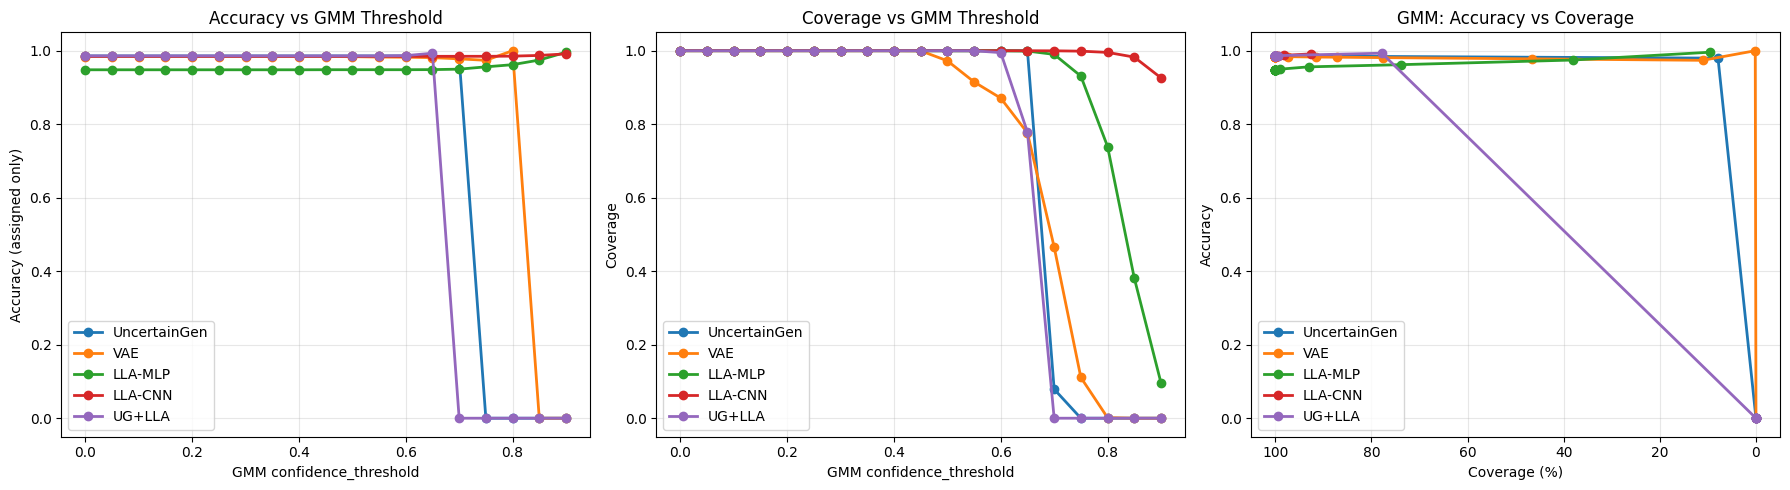

UncertainGen     best acc=0.9858 at threshold=0.00 (coverage=100.0%)
VAE              best acc=1.0000 at threshold=0.80 (coverage=0.1%)
LLA-MLP          best acc=0.9959 at threshold=0.90 (coverage=9.6%)
LLA-CNN          best acc=0.9914 at threshold=0.90 (coverage=92.6%)
UG+LLA           best acc=0.9932 at threshold=0.65 (coverage=77.8%)


In [194]:
# GMM confidence threshold sweep for probabilistic models
thresholds = np.arange(0.0, 0.95, 0.05)

gmm_sweep = {name: {"acc": [], "cov": [], "f1": []}
             for name, _, _ in prob_embs}

for name, emb_obj, unc in prob_embs:
    for thr in thresholds:
        gmm = GMMClusterer(n_components=10, confidence_threshold=thr, random_state=SEED)
        pred = gmm.fit_predict(emb_obj)
        mask = pred != -1
        n_assigned = mask.sum()
        coverage = n_assigned / len(pred)

        if n_assigned == 0:
            gmm_sweep[name]["acc"].append(0)
            gmm_sweep[name]["f1"].append(0)
            gmm_sweep[name]["cov"].append(0)
            continue

        label_map = align_labels_via_hungarian_algorithm(test_labels[mask], pred[mask])
        aligned = np.array([label_map.get(p, p) for p in pred[mask]])
        acc = accuracy_score(test_labels[mask], aligned)
        f1 = f1_score(test_labels[mask], aligned, average="macro")

        gmm_sweep[name]["acc"].append(acc)
        gmm_sweep[name]["f1"].append(f1)
        gmm_sweep[name]["cov"].append(coverage)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (name, res), c in zip(gmm_sweep.items(), colors):
    axes[0].plot(thresholds, res["acc"], "o-", label=name, color=c, linewidth=2)
    axes[1].plot(thresholds, res["cov"], "o-", label=name, color=c, linewidth=2)
    axes[2].plot([cov * 100 for cov in res["cov"]], res["acc"], "o-", label=name, color=c, linewidth=2)

axes[0].set_xlabel("GMM confidence_threshold")
axes[0].set_ylabel("Accuracy (assigned only)")
axes[0].set_title("Accuracy vs GMM Threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("GMM confidence_threshold")
axes[1].set_ylabel("Coverage")
axes[1].set_title("Coverage vs GMM Threshold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel("Coverage (%)")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("GMM: Accuracy vs Coverage")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].invert_xaxis()

plt.tight_layout()
plt.show()

# Print key points
for name, res in gmm_sweep.items():
    best_idx = np.argmax(res["acc"])
    print(f"{name:15s}  best acc={res['acc'][best_idx]:.4f} "
          f"at threshold={thresholds[best_idx]:.2f} (coverage={res['cov'][best_idx]:.1%})")

## 9. Comparison Summary

In [195]:
import pandas as pd

df = pd.DataFrame(results).set_index("name")
display(df.style.format({
    "acc": "{:.4f}", "nmi": "{:.4f}", "ari": "{:.4f}",
    "f1": "{:.4f}", "coverage": "{:.1%}",
}).highlight_max(axis=0, subset=["acc", "nmi", "ari", "f1"], color="blue"))

,acc,nmi,ari,f1,k,coverage
name,,,,,,
KMeans / MLP,0.9585,0.8970,0.9113,0.9580,10,100.0%
KMeans / CNN,0.9837,0.9543,0.9642,0.9837,10,100.0%
KMeans / UncertainGen,0.9854,0.9589,0.9679,0.9854,10,100.0%
KMeans / VAE,0.9832,0.9539,0.9631,0.9832,10,100.0%
KMeans / LLA-MLP,0.9585,0.8970,0.9113,0.9580,10,100.0%
KMeans / LLA-CNN,0.9837,0.9543,0.9642,0.9837,10,100.0%
KMeans / UG+LLA,0.9854,0.9589,0.9679,0.9854,10,100.0%
GMM / MLP,0.9481,0.8861,0.8879,0.9485,10,100.0%
GMM / CNN,0.9846,0.9570,0.9662,0.9846,10,100.0%
